In [1]:
import numpy as np
import skimage as ski
import sys
from scipy import ndimage as ndi
from matplotlib import pyplot as plt

In [2]:
import struct

def write_bin_img(file_name, img_out, type = 'uint8'):
    # Open the file in write-binary mode ('wb')
    with open(file_name, 'wb') as f:
        # 1. Write a two 2-byte unsigned short containing height and width of image
        f.write(np.uint16(img_out.shape[0]))
        f.write(np.uint16(img_out.shape[1]))

        # 2. Write a 2-byte unsigned short containing number of planes
        if (len(img_out.shape) == 2):
            f.write(np.uint16(1))
        elif (len(img_out.shape) == 3):
            f.write(np.uint16(img_out.shape[2]))
        else:
            return -1
        
        # 3. Write a 2-byte unsigned short containing pixel size in bytes followed by pixel data
        if (type == 'uint8'):
            f.write(np.uint16(1))
            if (len(img_out.shape) == 2):
                f.write(np.uint8(img_out.flatten()))
            elif (len(img_out.shape) == 3):
                for p in range(img_out.shape[2]):
                    f.write(np.uint8(img_out[:,:,p].flatten()))
        elif (type == 'uint16'):
            f.write(np.uint16(2))
            if (len(img_out.shape) == 2):
                f.write(np.uint16(img_out.flatten()))
            elif (len(img_out.shape) == 3):
                for p in range(img_out.shape[2]):
                    f.write(np.uint16(img_out[:,:,p].flatten()))
        elif (type == 'uint32'):
            f.write(np.uint16(4))
            if (len(img_out.shape) == 2):
                f.write(np.uint32(img_out.flatten()))
            elif (len(img_out.shape) == 3):
                for p in range(img_out.shape[2]):
                    f.write(np.uint32(img_out[:,:,p].flatten()))
        else:
            return -1


def read_bin_img(file_name):
    # Open the file in read-binary mode ('rb')
    with open(file_name, 'rb') as f:
        # 1. Read a two 2-byte unsigned short containing height and width of image
        image_shape = [0, 0]    
        
        data_bytes = f.read(2)
        image_shape[0] = struct.unpack('<H', data_bytes)[0]

        data_bytes = f.read(2)
        image_shape[1] = struct.unpack('<H', data_bytes)[0]

        print(f"Image shape: {image_shape}")

        print(f"Image height: {image_shape[0]}")
        print(f"Image width: {image_shape[1]}")

        # 2. Read a 2-byte unsigned short containing number of planes
        data_bytes = f.read(2)
        planes = struct.unpack('<H', data_bytes)[0]
        print(f"Number of image planes: {planes}")

        # 3. Read a 2-byte unsigned short containing pixel size in bytes
        data_bytes = f.read(2)
        pixel_size = struct.unpack('<H', data_bytes)[0]
        print(f"Pixel size in bytes: {pixel_size}")
    
        # 4. Initialize image matrix

        if (pixel_size == 1):
            image = np.zeros((image_shape[0], image_shape[1], planes), dtype=np.uint8)
        elif (pixel_size == 2):
            image = np.zeros((image_shape[0], image_shape[1], planes), dtype=np.uint16)
        elif (pixel_size == 4):
            image = np.zeros((image_shape[0], image_shape[1], planes), dtype=np.uint32)
        else:
            return -1
        
        # 5. Read pixel data

        for p in range(planes):
            for row in range(image_shape[0]):
                for col in range(image_shape[1]):
                    data_bytes = f.read(pixel_size)
                    if (pixel_size == 1):
                        image[row, col, p] = struct.unpack('<B', data_bytes)[0]
                    elif (pixel_size == 2):
                        image[row, col, p] = struct.unpack('<H', data_bytes)[0]
                    elif (pixel_size == 4):
                        image[row, col, p] = struct.unpack('<I', data_bytes)[0]
                    else:
                        return -1

        # 6. Reshape image to 2D or 3D array
        
        if (planes == 1):
            image = np.array(image).reshape((image_shape[0], image_shape[1]))
        else:
            image = np.array(image).reshape((image_shape[0], image_shape[1], planes))
        
        return image

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the binary data
with open('lena512_our.bin', 'rb') as f:
    data = f.read()

# 2. Convert to 8-bit Unsigned (uint8)
# This will result in exactly 262,144 elements
pixels = np.frombuffer(data, dtype=np.uint8)

# 3. Define the standard dimensions
width, height = 512, 512

# 4. Reshape
# No offset needed since 512*512 matches the byte count perfectly
image_array = pixels.reshape((height, width))

# 5. Display
plt.figure(figsize=(8, 8))
plt.imshow(image_array, cmap='gray')
plt.title("Lena 512x512 (8-bit Unsigned)")
plt.axis('off') # Hide axes for a cleaner look
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'lena512_our.bin'

Image shape: [512, 768]
Image height: 512
Image width: 768
Number of image planes: 3
Pixel size in bytes: 1


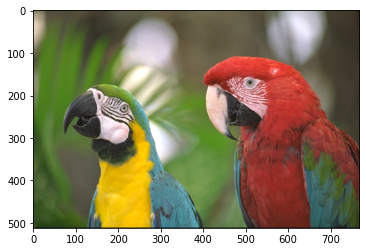

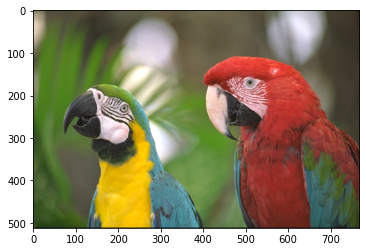

In [4]:
### Create bin file from color image

img = ski.io.imread('parrots.png')
plt.figure()
plt.imshow(img);

write_bin_img('parrots.bin', img, type='uint8')

img_bin = read_bin_img('parrots.bin')
plt.figure()
plt.imshow(img_bin);

Image shape: [512, 512]
Image height: 512
Image width: 512
Number of image planes: 1
Pixel size in bytes: 1

Scale factor: 0.333251953125
Scale factor INT VALUE: 1365

[[1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]
 [1214 1214 1214 1214 1214 1214 1214 1214 1214]]

Sum of fixed point scaled coeffs: 1.000060960650444

Fixed point scaled error: 7.526006227664972e-07



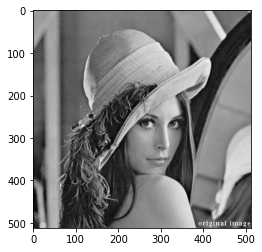

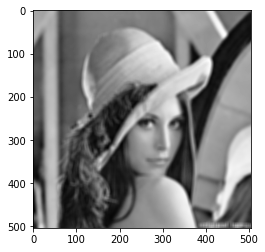

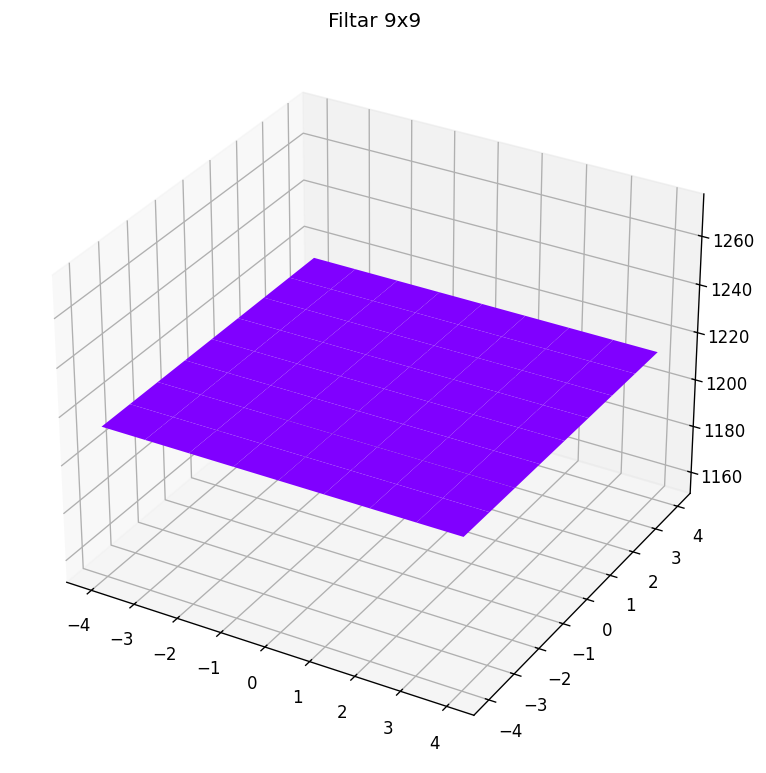

In [5]:
COEFF_FRACTIONAL_BITS = 15
SCALE_FACTOR_FRACTIONAL_BITS = 12

SIGNED_OUT_FRACTIONAL_BITS = 7
SIGNED_OUT_INTEGER_BITS = 9

UNSIGNED_OUT_BITS = 8

SIGNED_OUTPUT = True ## Za LoG filtar izlaz treba da bude označen

radius = 4

dirac = np.zeros((9, 9))
dirac[4, 4] = 1

dx = list(range(-4,5))
dy = list(range(-4,5))

dX, dY = np.meshgrid(dx, dy)


### Idealni filtar za usrednjavanje - box filtar ###

h_filter_box = (abs(dX) <= radius) & (abs(dY) <= radius) 
h_filter_box = h_filter_box / np.sum(h_filter_box.flatten())

####################################################


### Gausov filtar za usrednjavanje ##################

sigma = 1
h_filter_gauss = np.exp(-(np.square(dX) + np.square(dY))/(2*(sigma**2)))
h_filter_gauss[(abs(dX) > radius) | (abs(dY) > radius)] = 0
h_filter_gauss = h_filter_gauss / np.sum(h_filter_gauss.flatten())

#####################################################


### LoG (Laplacian of Gaussian) filtar ##############

sigma = 1
#h_filter_log = ndi.gaussian_laplace(dirac, sigma=sigma)
h_filter_log = -1/(np.pi*sigma**4)*(1 - (dX**2 + dY**2)/(2*sigma**2))*np.exp(-(np.square(dX) + np.square(dY))/(2*(sigma**2)))
h_filter_log[(abs(dX) > radius) | (abs(dY) > radius)] = 0

#####################################################

### Sharpen filter ##################################

k = 1

h_filter_sharpen_box = (1+k)*dirac - k*h_filter_box

h_filter_sharpen_gauss = (1+k)*dirac - k*h_filter_gauss

#####################################################

h_filter = h_filter_box

img = read_bin_img('lena_512.bin')

plt.figure()
if (len(img.shape) == 2):
    plt.imshow(img, cmap = 'gray');
    img_filtered = np.zeros((img.shape[0]-2*radius, img.shape[1]-2*radius))
    img_out_full = ndi.correlate(img.astype(np.float64), h_filter)
    img_filtered = img_out_full[radius:img.shape[0]-radius, radius:img.shape[1]-radius]

    plt.figure()
    if (SIGNED_OUTPUT):
        img_filtered = np.clip(img_filtered, -2**(SIGNED_OUT_INTEGER_BITS-1), 2**(SIGNED_OUT_INTEGER_BITS-1) - 1/2**SIGNED_OUT_FRACTIONAL_BITS)
        plt.imshow((img_filtered + 2**(SIGNED_OUT_INTEGER_BITS-1))/(2**SIGNED_OUT_INTEGER_BITS - 1/2**SIGNED_OUT_FRACTIONAL_BITS), cmap = 'gray');
    else:
        img_filtered = np.clip(img_filtered, 0, 2**UNSIGNED_OUT_BITS - 1)
        plt.imshow(img_filtered.astype(np.uint8), cmap = 'gray');

    
    
else:
    plt.imshow(img);
    img_filtered = np.zeros((img.shape[0]-2*radius, img.shape[1]-2*radius, 3))
    img_out_full = np.zeros(img.shape)
    for p in range(0,3):
        img_out_full[:,:,p] = ndi.correlate(img[:,:,p].astype(np.float64), h_filter)
    
    img_filtered = img_out_full[radius:img.shape[0]-radius, radius:img.shape[1]-radius, :]

    plt.figure()
    if (SIGNED_OUTPUT):
        img_filtered = np.clip(img_filtered, -2**(SIGNED_OUT_INTEGER_BITS-1), 2**(SIGNED_OUT_INTEGER_BITS-1) - 1/2**SIGNED_OUT_FRACTIONAL_BITS)
        plt.imshow((img_filtered + 2**(SIGNED_OUT_INTEGER_BITS-1))/(2**SIGNED_OUT_INTEGER_BITS - 1/2**SIGNED_OUT_FRACTIONAL_BITS));
    else:
            img_filtered = np.clip(img_filtered, 0, 2**UNSIGNED_OUT_BITS - 1)
            plt.imshow(img_filtered.astype(np.uint8));



### COEFFICIENT QUANTIZATION #######################

inv_scale_factor = 3

scale_factor = np.round((1 / inv_scale_factor) * 2**SCALE_FACTOR_FRACTIONAL_BITS)

print('\nScale factor: ' + str(scale_factor/2**SCALE_FACTOR_FRACTIONAL_BITS))
print('Scale factor INT VALUE: ' + str(scale_factor.astype(np.uint16)) + '\n')

h_filter_fxp = np.round(h_filter * 2**COEFF_FRACTIONAL_BITS * inv_scale_factor)
print(h_filter_fxp.astype(np.int16))

h_filter_fxp_scaled = h_filter_fxp * scale_factor / 2**SCALE_FACTOR_FRACTIONAL_BITS     

print('\nSum of fixed point scaled coeffs: ' + str(np.sum(h_filter_fxp_scaled/2**COEFF_FRACTIONAL_BITS)))
print('\nFixed point scaled error: ' + str(np.max(np.abs(h_filter_fxp_scaled/2**COEFF_FRACTIONAL_BITS - h_filter))) + '\n')

fig = plt.figure(figsize=(8,8), dpi=120)
ax = plt.axes(projection='3d')
ax.plot_surface(dX, dY, np.round(h_filter * 2**COEFF_FRACTIONAL_BITS * inv_scale_factor), cmap='rainbow'); ax.set_title('Filtar 9x9');


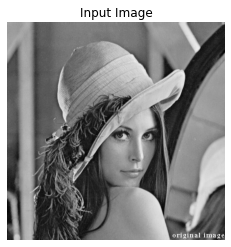

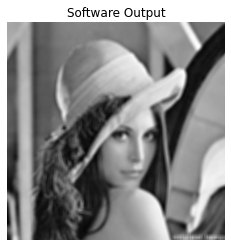


SHIFT FOUND:
Row shift: -10
Col shift: -10
Mismatch: 243948

Total mismatches: 253962


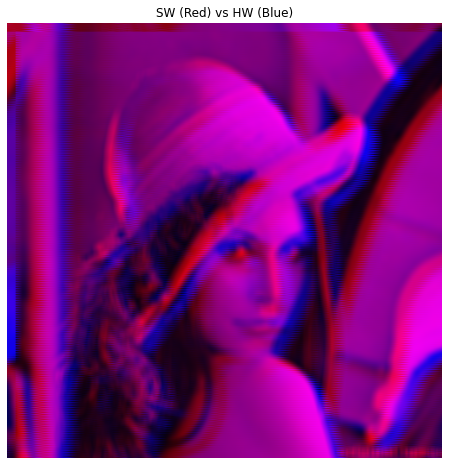

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage import img_as_ubyte


# =========================================================
# PARAMETERS (MATCH RTL)
# =========================================================
R = 4
COEFF = 405
COEFF_SCALE = 4096


# =========================================================
# LOAD IMAGE
# =========================================================
def load_lena(path="lena.tif"):
    img = io.imread(path, as_gray=True)
    img = img_as_ubyte(img)
    return img.astype(np.uint8)


# =========================================================
# DISPLAY IMAGE
# =========================================================
def show(img, title="img"):
    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis("off")
    plt.show()


# =========================================================
# SIGNED VIEW (VHDL STYLE)
# =========================================================
def to_signed(a, bits):
    if bits == 8:
        return a.astype(np.uint8).view(np.int8)
    if bits == 16:
        return a.astype(np.uint16).view(np.int16)
    if bits == 32:
        return a.astype(np.uint32).view(np.int32)
    raise ValueError()


# =========================================================
# 9x9 BOX FILTER (FLAT FOR C-STYLE ACCESS)
# =========================================================
def box_filter():
    return np.full((9, 9), COEFF, dtype=np.int16).flatten()


# =========================================================
# SOFTWARE REFERENCE (RTL MATCH)
# =========================================================
def sw_filter(img, coeffs):

    coeffs = np.asarray(coeffs).flatten()

    H, W = img.shape

    out = np.zeros((H - 2*R, W - 2*R), dtype=np.int16)

    for i in range(R, H - R):
        for j in range(R, W - R):

            acc = 0
            k = 0

            for dr in range(R, -R-1, -1):
                for dc in range(R, -R-1, -1):

                    pix = int(img[i + dr, j + dc])
                    coeff = int(coeffs[k])

                    acc += pix * coeff
                    k += 1

            scaled = np.int64(acc) * np.int64(COEFF_SCALE)
            res = np.int32(scaled >> 20)

            if res > 32767:
                res = 32767
            elif res < -32768:
                res = -32768

            out[i - R, j - R] = np.int16(res)

    return out


# =========================================================
# LOAD HARDWARE OUTPUT
# =========================================================
def load_hw(file, h, w):
    d = np.fromfile(file, dtype=np.int16)
    return d.reshape((h, w))


# =========================================================
# FIND SHIFT (PIPELINE LATENCY DETECTION)
# =========================================================
def find_shift(ref, hw, max_shift=10):

    best = 1e18
    br, bc = 0, 0

    for r in range(-max_shift, max_shift+1):
        for c in range(-max_shift, max_shift+1):

            r0 = max(0, r)
            r1 = min(ref.shape[0], hw.shape[0] + r)

            c0 = max(0, c)
            c1 = min(ref.shape[1], hw.shape[1] + c)

            hr0 = max(0, -r)
            hr1 = min(hw.shape[0], ref.shape[0] - r)

            hc0 = max(0, -c)
            hc1 = min(hw.shape[1], ref.shape[1] - c)

            if r1 <= r0 or c1 <= c0:
                continue

            a = ref[r0:r1, c0:c1]
            b = hw[hr0:hr1, hc0:hc1]

            err = np.sum(a != b)

            if err < best:
                best = err
                br, bc = r, c

    print("\nSHIFT FOUND:")
    print("Row shift:", br)
    print("Col shift:", bc)
    print("Mismatch:", best)

    return br, bc


# =========================================================
# ALIGN MATRIX
# =========================================================
def align(mat, r, c):
    return np.roll(mat, (-r, -c), axis=(0, 1))


# =========================================================
# COMPARE
# =========================================================
def compare(ref, hw):

    ref_s = to_signed(ref, 16)
    hw_s = to_signed(hw, 16)

    mismatch = ref_s != hw_s

    print("\nTotal mismatches:", np.sum(mismatch))

    return mismatch


# =========================================================
# RED / BLUE OVERLAY (NO ERROR CHANNEL)
# =========================================================
def overlay_rb(sw, hw):

    sw = sw.astype(np.float32)
    hw = hw.astype(np.float32)

    # normalize independently
    sw = (sw - sw.min()) / (sw.max() - sw.min() + 1e-9)
    hw = (hw - hw.min()) / (hw.max() - hw.min() + 1e-9)

    img = np.zeros((*sw.shape, 3), dtype=np.float32)

    img[..., 0] = sw   # RED  = software
    img[..., 2] = hw   # BLUE = hardware

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title("SW (Red) vs HW (Blue)")
    plt.axis("off")
    plt.show()


# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    # -------------------------
    # INPUT IMAGE
    # -------------------------
    img = load_lena("lena.tif")
    show(img, "Input Image")

    # -------------------------
    # SOFTWARE FILTER
    # -------------------------
    coeffs = box_filter()
    sw = sw_filter(img, coeffs)

    show(sw.astype(np.float32), "Software Output")

    # -------------------------
    # HARDWARE OUTPUT
    # -------------------------
    hw = load_hw("lena_512_fresh.bin", sw.shape[0], sw.shape[1])

    # -------------------------
    # FIND SHIFT
    # -------------------------
    r, c = find_shift(sw, hw, max_shift=10)

    # -------------------------
    # ALIGN
    # -------------------------
    hw_aligned = align(hw, r, c)

    # -------------------------
    # COMPARE
    # -------------------------
    compare(sw, hw_aligned)

    # -------------------------
    # OVERLAY (RED / BLUE ONLY)
    # -------------------------
    overlay_rb(sw, hw_aligned)

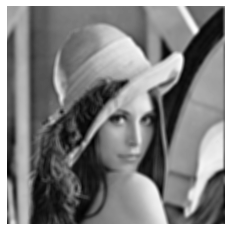

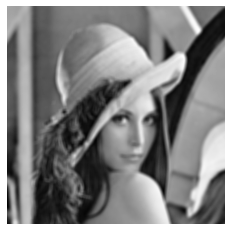

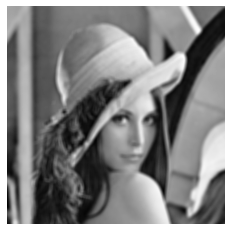

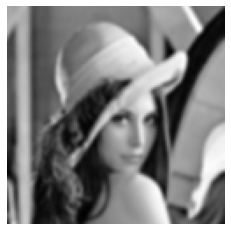

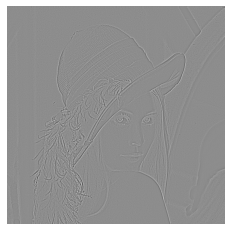

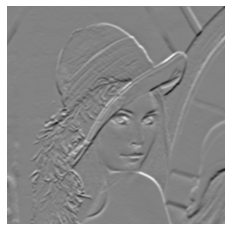

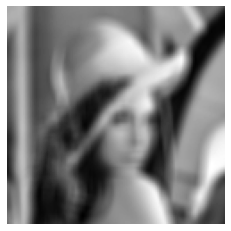

In [2]:
import numpy as np
import struct

# =========================
# WRITE (RAW IMAGE ONLY)
# =========================
def write_bin_img(file_name, img_out, type='uint8'):

    with open(file_name, 'wb') as f:

        # ---------------------
        # UINT8
        # ---------------------
        if type == 'uint8':

            if img_out.ndim == 2:
                f.write(img_out.astype(np.uint8).tobytes())

            elif img_out.ndim == 3:
                for p in range(img_out.shape[2]):
                    f.write(img_out[:, :, p].astype(np.uint8).tobytes())

            else:
                raise ValueError("Invalid image shape")

        # ---------------------
        # Q9.7 (int16)
        # ---------------------
        elif type == 'q9_7':

            img_fixed = (img_out * 128).astype(np.int16)

            if img_fixed.ndim == 2:
                f.write(img_fixed.tobytes())

            elif img_fixed.ndim == 3:
                for p in range(img_fixed.shape[2]):
                    f.write(img_fixed[:, :, p].tobytes())

            else:
                raise ValueError("Invalid image shape")

        else:
            raise ValueError("type must be 'uint8' or 'q9_7'")


# =========================
# READ (RAW IMAGE ONLY)
# =========================
def read_bin_img(file_name, height, width, planes=1, type='uint8'):

    # ---------------------
    # dtype selection
    # ---------------------
    if type == 'uint8':
        dtype = np.uint8

    elif type == 'q9_7':
        dtype = np.int16

    else:
        raise ValueError("type must be 'uint8' or 'q9_7'")

    # ---------------------
    # load raw data
    # ---------------------
    data = np.fromfile(file_name, dtype=dtype)

    expected = height * width * planes

    if data.size != expected:
        raise ValueError(
            f"Size mismatch: expected {expected}, got {data.size}"
        )

    # ---------------------
    # reshape
    # ---------------------
    if planes == 1:
        img = data.reshape((height, width))

    else:
        img = np.zeros((height, width, planes), dtype=dtype)

        idx = 0
        plane_size = height * width

        for p in range(planes):
            img[:, :, p] = data[idx:idx + plane_size].reshape((height, width))
            idx += plane_size

    # ---------------------
    # Q9.7 conversion
    # ---------------------
    if type == 'q9_7':
        img = img.astype(np.float32) / 128.0

    return img

def show_img(img):
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img.astype(np.float32))
    plt.axis('off')
    plt.show()


# img1 = read_bin_img("lena_512_novo.bin", 504, 504, type='q9_7')
# show_img(img1)

img2 = read_bin_img("lena_512_uint8_blur.bin", 504, 504, type='uint8')
show_img(img2)

img3= read_bin_img("lena_512_clean_filtered_9x9_signed.bin", 504, 504, type='q9_7')
show_img(img3)

img4 = read_bin_img("lena_512_clean_filtered_9x9_referent_signed.bin", 504, 504, type='q9_7')
show_img(img4)

img5 = read_bin_img("lena_128_gaus_rad2.bin", 124, 124, type='q9_7')
show_img(img5)

img5 = read_bin_img("lena_512_log_rad1.bin", 510, 510, type='q9_7')
show_img(img5)


img6 = read_bin_img("lena_512_sobely_rad4.bin", 504, 504, type='q9_7')
show_img(img6)

img7 = read_bin_img("lena_128_box.bin", 122, 122, type='uint8')
show_img(img7)


In [68]:
# %%
# ─────────────────────────────────────────────────────────────────────────────
# filter_compare.py
# Three-way comparison: HW result | SW (C) reference | Python reference / Source
#
# Paste cells into Jupyter or run as a plain .py file.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import correlate          # correlation = same as C inner loop

# ─────────────────────────────────────────────────────────────────────────────
# %%  CONFIG  ← change these to match your C #defines
# ─────────────────────────────────────────────────────────────────────────────
FILTER_TYPE   = 'sobel_x'   # 'box' | 'gaussian' | 'log' | 'sobel_x' | 'sobel_y'
                             # 'laplacian' | 'sharpen_box' | 'sharpen_gauss'
FILTER_RADIUS = 2            # matches FILTER_RADIUS in main.c (1→3x3, 2→5x5 …)
IMG_W, IMG_H  = 128, 128
IMG_PLANES    = 1            # 1 = grayscale, 3 = RGB planar
OUT_MODE      = 'q9_7'      # 'uint8' | 'q9_7'

# ── BYPASS CONFIGURATION ─────────────────────────────────────────────────────
BYPASS_MODE   = True        # Set to True if hardware is running in bypass mode (no crop)

# Output crop size (used only when filtering path is active)
OUT_H = IMG_H - 2 * FILTER_RADIUS
OUT_W = IMG_W - 2 * FILTER_RADIUS

HW_BIN = "lena_128_bypass.bin"       # from  mrd -bin … result.bin
SW_BIN = "lena_128_bypass_ref.bin"   # from  mrd -bin … sw_ref.bin
SRC_BIN = "lena_128_clean.bin"            # original input image


# ─────────────────────────────────────────────────────────────────────────────
# %%  I/O helpers (planar binary, same layout as C driver)
# ─────────────────────────────────────────────────────────────────────────────
def read_bin(path, height, width, planes=1, dtype='uint8'):
    """Read a planar binary: [R plane][G plane][B plane], each H×W."""
    raw_dt = np.uint8 if dtype == 'uint8' else np.int16
    data   = np.fromfile(path, dtype=raw_dt)
    exp    = height * width * planes
    if data.size != exp:
        raise ValueError(f"{path}: expected {exp} values, got {data.size}")
    ps = height * width
    if planes == 1:
        img = data.reshape(height, width)
    else:
        img = np.stack(
            [data[p*ps:(p+1)*ps].reshape(height, width) for p in range(planes)],
            axis=2
        )
    return img.astype(np.float32) / 128.0 if dtype == 'q9_7' else img


def write_bin(path, img, dtype='uint8'):
    """Write image as planar binary."""
    with open(path, 'wb') as f:
        out = img.astype(np.uint8) if dtype == 'uint8' \
              else np.clip(np.round(img * 128), -32768, 32767).astype(np.int16)
        if out.ndim == 2:
            f.write(out.tobytes())
        else:
            for p in range(out.shape[2]):
                f.write(out[:, :, p].tobytes())


# ─────────────────────────────────────────────────────────────────────────────
# %%  KERNEL BUILDER  (mirrors GenerateCoeffsMath in main.c exactly)
# ─────────────────────────────────────────────────────────────────────────────
def build_kernel(filter_type, radius):
    """
    Returns a normalised float32 kernel that matches what GenerateCoeffsMath
    produces in C.
    """
    K     = 2 * radius + 1
    sigma = radius / 2.0 if radius > 0 else 1.0
    k     = np.zeros((K, K), dtype=np.float64)

    # ── sharpening ────────────────────────────────────────────────────────────
    if filter_type in ('sharpen_box', 'sharpen_gauss'):
        lp = np.ones((K, K), dtype=np.float64) if filter_type == 'sharpen_box' \
             else np.fromfunction(
                 lambda r, c: np.exp(-((r-radius)**2 + (c-radius)**2) / (2*sigma**2)),
                 (K, K), dtype=np.float64)
        lp_norm = lp / lp.sum()
        delta = np.zeros((K, K), dtype=np.float64)
        delta[radius, radius] = 1.0
        return (2*delta - lp_norm).astype(np.float32)

    # ── all other types ───────────────────────────────────────────────────────
    for r in range(K):
        for c in range(K):
            dy, dx   = float(r - radius), float(c - radius)
            dist_sq  = dx*dx + dy*dy
            if   filter_type == 'box':
                k[r, c] = 1.0
            elif filter_type == 'gaussian':
                k[r, c] = np.exp(-dist_sq / (2*sigma**2))
            elif filter_type == 'log':
                k[r, c] = (dist_sq/sigma**2 - 2) * np.exp(-dist_sq/(2*sigma**2))
            elif filter_type == 'sobel_x':
                k[r, c] = 0.0 if dist_sq == 0 else dx / dist_sq
            elif filter_type == 'sobel_y':
                k[r, c] = 0.0 if dist_sq == 0 else dy / dist_sq
            elif filter_type == 'laplacian':
                k[r, c] = -(K*K - 1) if (dx == 0 and dy == 0) else 1.0
            else:
                raise ValueError(f"Unknown filter type: {filter_type}")

    # zero-mean for edge detectors (matches C code)
    if filter_type in ('log', 'laplacian', 'sobel_x', 'sobel_y'):
        k    -= k.mean()
        psum  = k[k > 0].sum()
        if psum > 0:
            k /= psum
    else:
        s = k.sum()
        if s != 0:
            k /= s

    return k.astype(np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# %%  PYTHON REFERENCE FILTER
# ─────────────────────────────────────────────────────────────────────────────
def apply_filter_py(img, kernel, output_mode='uint8'):
    """
    Convolve `img` with `kernel` using cross-correlation (matches C loop),
    crop the 2R-pixel border, and return in the requested format.
    """
    R = kernel.shape[0] // 2

    def _proc_plane(plane_2d):
        out = correlate(plane_2d.astype(np.float32), kernel, mode='nearest')
        out = out[R:IMG_H-R, R:IMG_W-R]           # crop exactly like HW/SW
        if output_mode == 'uint8':
            return np.clip(np.round(out), 0, 255).astype(np.uint8)
        else:
            return out.astype(np.float32)

    if img.ndim == 2:
        return _proc_plane(img)
    else:
        return np.stack([_proc_plane(img[:, :, p]) for p in range(img.shape[2])],
                        axis=2)


# ─────────────────────────────────────────────────────────────────────────────
# %%  LOAD EVERYTHING AND PROCESS
# ─────────────────────────────────────────────────────────────────────────────
# Original source image (always raw size)
img_src = read_bin(SRC_BIN, IMG_H, IMG_W, planes=IMG_PLANES, dtype='uint8')

if BYPASS_MODE:
    print("!! BYPASS MODE ACTIVE !! Reading full layout (no cropping applied).")
    
    # Read outputs at full raw image dimensions
    img_hw  = read_bin(HW_BIN,  IMG_H, IMG_W, planes=IMG_PLANES, dtype=OUT_MODE)
    img_sw  = read_bin(SW_BIN,  IMG_H, IMG_W, planes=IMG_PLANES, dtype=OUT_MODE)
    
    img_third   = img_src
    third_label = "Original Source Image"
else:
    print(f"Normal Filtering Mode Active: Expecting cropped output border (2R={2*FILTER_RADIUS}px).")
    # Read outputs using the hardware border-cropped dimensions
    img_hw  = read_bin(HW_BIN,  OUT_H, OUT_W, planes=IMG_PLANES, dtype=OUT_MODE)
    img_sw  = read_bin(SW_BIN,  OUT_H, OUT_W, planes=IMG_PLANES, dtype=OUT_MODE)
    
    kernel  = build_kernel(FILTER_TYPE, FILTER_RADIUS)
    print(f"Kernel  [{FILTER_TYPE}, R={FILTER_RADIUS}]  shape={kernel.shape}")
    
    img_third   = apply_filter_py(img_src, kernel, output_mode=OUT_MODE)
    third_label = "Python reference (scipy)"

print(f"\nHW   : {img_hw.shape}  {img_hw.dtype}")
print(f"SW   : {img_sw.shape}  {img_sw.dtype}")
print(f"REF  : {img_third.shape}  {img_third.dtype}")


# ─────────────────────────────────────────────────────────────────────────────
# %%  DISPLAY HELPER
# ─────────────────────────────────────────────────────────────────────────────
def _to_display(img):
    """Normalise any image to float32 [0,1] suitable for imshow."""
    f = img.astype(np.float32)
    if img.dtype == np.uint8:
        return f / 255.0, (None if img.ndim == 3 else 'gray')
    lo, hi = f.min(), f.max()
    d = (f - lo) / (hi - lo + 1e-9)
    return d, (None if img.ndim == 3 else 'gray')


# ─────────────────────────────────────────────────────────────────────────────
# %%  THREE-WAY COMPARISON PLOT
# ─────────────────────────────────────────────────────────────────────────────
def compare_three(hw, sw, third, label_third, mode=OUT_MODE):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                             gridspec_kw={'wspace': 0.05})

    labels = ['HW result', 'SW reference (C)', label_third]
    for ax, img, label in zip(axes, [hw, sw, third], labels):
        d, cmap = _to_display(img)
        ax.imshow(d, cmap=cmap)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.axis('off')

    title_prefix = "BYPASS MODE (No Crop)" if BYPASS_MODE else f"{FILTER_TYPE.upper()} R={FILTER_RADIUS}"
    fig.suptitle(
        f"{title_prefix}   ({IMG_W}×{IMG_H} → {hw.shape[1]}×{hw.shape[0]})   mode={mode}",
        fontsize=13, fontweight='bold'
    )
    plt.show() 

compare_three(img_hw, img_sw, img_third, third_label)

!! BYPASS MODE ACTIVE !! Reading full layout (no cropping applied).


FileNotFoundError: [Errno 2] No such file or directory: 'lena_128_bypass.bin'

In [62]:
pokreni_vizualizaciju(
    image="parrots", 
    filter_type="box", 
    radius=3, 
    result_bin="parrot_box.bin", 
    ref_bin="sw_ref.bin"
)

NameError: name 'pokreni_vizualizaciju' is not defined

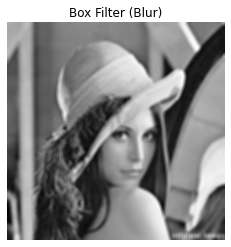

In [18]:
# Box filter (mean filter)
from scipy import ndimage
img = ski.io.imread("lena.tif")
box_size = 9
kernel = np.ones((box_size, box_size)) / (box_size ** 2)

img_box = ndimage.convolve(img, kernel)

plt.imshow(img_box, cmap='gray')
plt.title("Box Filter (Blur)")
plt.axis('off')
plt.show()
